##  Basic Library imports

In [2]:
import os
import pandas as pd 
import numpy as np

from utils import download_images

##  Read Dataset

In [6]:
DATASET_FOLDER = '../dataset/train_split'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part1.csv'))
# val_set = pd.read_csv(os.path.join(DATASET_FOLDER, '../dataset/val_split.csv'))

In [7]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, '../images/train_part1', download_images)
print(f"Missing images downloaded: {len(missing)}")



Missing: 81qga-Hz5dL.jpg
Missing: 71aupoPmPYL.jpg
Missing: 815KiIfEPuL.jpg
Missing: 61gorys3k4L.jpg
Missing: 71E6th2nUyL.jpg
Missing: 81+S1dKAK7L.jpg
Missing: 71YtI3Vm6fL.jpg


100%|██████████| 7/7 [00:02<00:00,  3.36it/s]

Missing images downloaded: 7


In [ ]:
download_images(train_set['image_link'], '../images/train_part1')

 17%|█▋        | 3341/20000 [02:39<05:08, 53.93it/s] 

<urlopen error [Errno 101] Network is unreachable>
<urlopen error [Errno 101] Network is unreachable>Warning: Not able to download - https://m.media-amazon.com/images/I/815KiIfEPuL.jpg
<urlopen error [Errno 101] Network is unreachable>

<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno 101] Network is unreachable>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>


Process ForkPoolWorker-92:
Process ForkPoolWorker-88:
Process ForkPoolWorker-90:
Process ForkPoolWorker-84:
Process ForkPoolWorker-98:
Process ForkPoolWorker-91:
Process ForkPoolWorker-100:
Process ForkPoolWorker-89:
Process ForkPoolWorker-9:
Process ForkPoolWorker-86:
Process ForkPoolWorker-83:
Process ForkPoolWorker-67:
Process ForkPoolWorker-93:
Process ForkPoolWorker-96:
Process ForkPoolWorker-94:
Process ForkPoolWorker-70:
Process ForkPoolWorker-95:
Process ForkPoolWorker-78:
Process ForkPoolWorker-46:
Process ForkPoolWorker-97:
Process ForkPoolWorker-82:
Process ForkPoolWorker-68:
Process ForkPoolWorker-65:
Process ForkPoolWorker-57:
Process ForkPoolWorker-99:
Process ForkPoolWorker-19:
Process ForkPoolWorker-30:
Process ForkPoolWorker-58:
Process ForkPoolWorker-23:
Process ForkPoolWorker-80:
Process ForkPoolWorker-79:
Traceback (most recent call last):
Process ForkPoolWorker-56:
Process ForkPoolWorker-39:
Traceback (most recent call last):
Process ForkPoolWorker-75:
Process Fork

In [9]:
assert len(os.listdir('../images/train_part1')) > 0

In [14]:
print("Total rows in CSV:", len(train_set))
print("Rows with null image_link:", train_set['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set[train_set['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 20000
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 19766
Unique image filenames (basenames): 19766
Files in image directory: 19766
Sample duplicate basenames:
image_link
51m1gdQJW2L.jpg    16
71LRdXdqc0L.jpg     8
71FMi9tO3HL.jpg     7
61md5v6UPNL.jpg     4
71-2e1dd79L.jpg     3
Name: count, dtype: int64
Image '915RX0K9R6L.jpg' has multiple prices: [18.99 22.99]
Image '61uSlZvKdML.jpg' has multiple prices: [ 4.94 15.04]
Image '41jqgaqp8ML.jpg' has multiple prices: [107.24 144.59]
Image '81QRXDV9EJL.jpg' has multiple prices: [31.75 75.71]
Image '71l1wIjPBWL.jpg' has multiple prices: [66.95 51.36]
Image '71FFPJCtd8L.jpg' has multiple prices: [3.88 4.19]
Image '91JO30DLimL.jpg' has multiple prices: [4.42 5.98]
Image '613VYsejdjL.jpg' has multiple prices: [15.95 20.19]
Image '31O4R53LrPL.jpg' has multiple prices: [4.49 7.83]
Image '81StckzbdXL.jpg' has multiple prices: [ 4.79 38.99]
Image '51m1gdQJW2L.jpg' has multiple prices: [ 15.57   

####  There are some rows that do not have an image at all.

Let's remove them

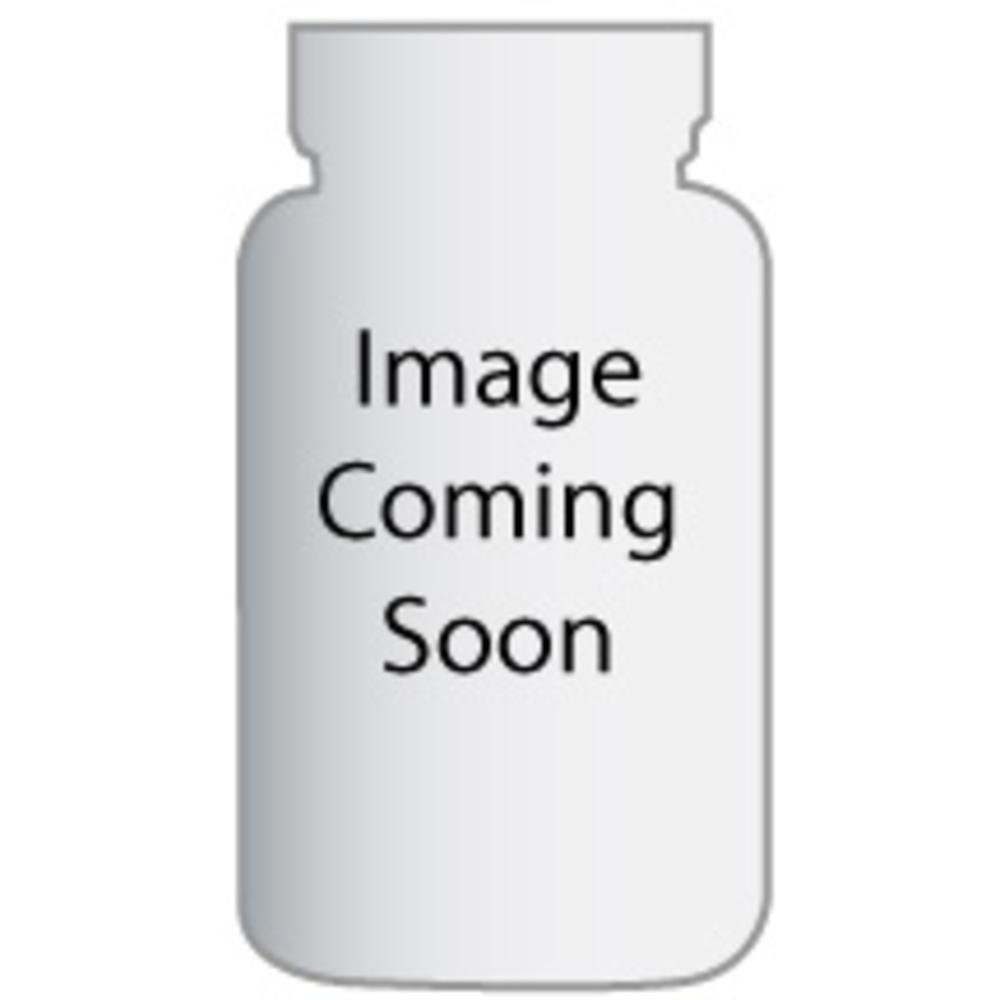

In [16]:
from IPython.display import Image, display

image_path = os.path.join('../images/train_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [17]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 16 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 10 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 16 rows removed.


In [3]:
import zipfile

images_dir = '../images/train_part2'
zip_path = '../train_part2.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../train_part2.zip


In [4]:
images_dir = '../images/train_part1'
zip_path = '../train_part1.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../train_part1.zip


In [ ]:
# rm -rf ../images